### my get frames (photon counting)

In [ ]:
import sys
import os
import tkinter as tk
from tkinter import ttk, messagebox, filedialog
import numpy as np
import threading
import queue
import time

# --- 1. 彻底解决弹窗问题 ---
from matplotlib.figure import Figure 
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib

# 强制使用 TkAgg 后端
matplotlib.use('TkAgg')

# --- 2. 路径设置 (请务必确认正确) ---
from pathlib import Path

# Auto-locate project paths: notebook is under .../SPAD python/control
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name.lower() != 'control':
    NOTEBOOK_DIR = Path(r'D:/OneDrive/foam_imaging_project/experiment_setup/SPAD python/control')
PROJECT_DIR = NOTEBOOK_DIR.parent
EXPERIMENT_DIR = PROJECT_DIR.parent
SDK_PATH = str(PROJECT_DIR / 'samples')
FIRMWARE_PATH = str(EXPERIMENT_DIR / 'Firmware' / 'PF32_USB3.bit')

# --- 3. 环境加载 ---
if os.path.exists(SDK_PATH):
    sys.path.append(SDK_PATH)
    if hasattr(os, 'add_dll_directory'):
        try: os.add_dll_directory(SDK_PATH)
        except: pass

try:
    from PF32_Factory import PF32_Factory
    from PF32_Camera import PF32_Camera
    mock_camera = False
except:
    print("未找到SDK，使用模拟模式")
    mock_camera = True

class PF32ZeroLatencyApp:
    def __init__(self, root):
        self.root = root
        self.root.title("PF32 Zero Latency (Purge Mode)")
        self.root.geometry("1000x800")
        
        self.camera = None
        self.factory = None
        self.is_live = False
        self.data_queue = queue.Queue(maxsize=1)
        self.last_snapshot = None
        
        # 初始化 UI 和 相机
        self.setup_ui()
        self.init_camera()
        
        self.root.protocol("WM_DELETE_WINDOW", self.on_close)

    def init_camera(self):
        if mock_camera: return
        try:
            self.factory = PF32_Factory(SDK_PATH)
            self.factory.setLogStreamLevel(PF32_Factory.LOGLEVEL_WARNING)
            if not os.path.exists(FIRMWARE_PATH):
                raise FileNotFoundError(f"固件文件丢失: {FIRMWARE_PATH}")
                
            self.camera = self.factory.PF_constructWithCustomFirmware(FIRMWARE_PATH)
            self.camera.setMode(PF32_Camera.MODE_PHOTON_COUNTING)
            self.camera.setEnableFooters(True)
            
            sn = self.camera.getSerialNumber()
            self.lbl_status.config(text=f"已连接 | SN: {sn}", foreground="green")
        except Exception as e:
            self.lbl_status.config(text="连接失败", foreground="red")
            messagebox.showerror("错误", f"相机初始化失败:\n{e}")

    def setup_ui(self):
        # 左侧面板
        panel = ttk.Frame(self.root, padding=10, width=250)
        panel.pack(side=tk.LEFT, fill=tk.Y)
        
        # 参数
        p_grp = ttk.LabelFrame(panel, text="参数", padding=5)
        p_grp.pack(fill=tk.X, pady=5)
        
        ttk.Label(p_grp, text="曝光 (us):").pack(anchor="w")
        self.exp_var = tk.IntVar(value=20) # 默认改小一点，曝光时间本身也是延迟
        ttk.Entry(p_grp, textvariable=self.exp_var).pack(fill=tk.X)
        
        # 翻转
        o_grp = ttk.LabelFrame(panel, text="方向", padding=5)
        o_grp.pack(fill=tk.X, pady=5)
        self.flip_v = tk.BooleanVar(value=True)
        ttk.Checkbutton(o_grp, text="上下翻转", variable=self.flip_v).pack(anchor="w")
        self.flip_h = tk.BooleanVar(value=False)
        ttk.Checkbutton(o_grp, text="左右镜像", variable=self.flip_h).pack(anchor="w")
        
        # 显示
        d_grp = ttk.LabelFrame(panel, text="显示", padding=5)
        d_grp.pack(fill=tk.X, pady=5)
        self.autoscale = tk.BooleanVar(value=True)
        ttk.Checkbutton(d_grp, text="自动对比度", variable=self.autoscale).pack(anchor="w")
        ttk.Label(d_grp, text="手动 Max:").pack(anchor="w")
        self.vmax_var = tk.IntVar(value=50)
        ttk.Entry(d_grp, textvariable=self.vmax_var).pack(fill=tk.X)

        # 按钮
        b_grp = ttk.LabelFrame(panel, text="操作", padding=10)
        b_grp.pack(fill=tk.X, pady=10)
        
        self.btn_live = ttk.Button(b_grp, text="▶ 实时", command=self.toggle_live)
        self.btn_live.pack(fill=tk.X, pady=5)
        
        ttk.Separator(b_grp).pack(fill=tk.X, pady=5)
        self.btn_snap = ttk.Button(b_grp, text="📷 单帧采集", command=self.snapshot)
        self.btn_snap.pack(fill=tk.X, pady=2)
        self.btn_save = ttk.Button(b_grp, text="💾 保存", command=self.save_file, state="disabled")
        self.btn_save.pack(fill=tk.X, pady=2)

        # 状态
        self.lbl_fps = ttk.Label(panel, text="FPS: 0")
        self.lbl_fps.pack(side=tk.BOTTOM)
        self.lbl_max = ttk.Label(panel, text="Max: 0")
        self.lbl_max.pack(side=tk.BOTTOM)
        self.lbl_status = ttk.Label(panel, text="就绪")
        self.lbl_status.pack(side=tk.BOTTOM, pady=10)

        # 右侧绘图 (无弹窗模式)
        plot_frame = ttk.Frame(self.root)
        plot_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.fig = Figure(figsize=(5, 5), dpi=100)

        # 调整边距，占满空间
        self.fig.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)
        self.ax = self.fig.add_subplot(111)
        self.ax.set_title("PF32 Real-Time Stream", fontsize=12, color='black') 
        self.ax.axis('off')

        # 初始化图像
        self.im = self.ax.imshow(np.zeros((32, 32)), cmap='inferno', animated=True, vmin=0, vmax=100)
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        
        self.bg = None

    def process_data(self, frame_obj):
        if mock_camera:
            t = time.time() * 10
            base = np.zeros((32,32))
            x, y = int(16 + 10 * np.sin(t)), int(16 + 10 * np.cos(t))
            base[np.clip(x,0,31), np.clip(y,0,31)] = 200
            return base
        
        raw = frame_obj.get_data()
        if len(raw) >= 1024:
            mat = np.array(raw[:1024], dtype=np.uint16).reshape(32, 32)
            if self.flip_v.get(): mat = np.flipud(mat)
            if self.flip_h.get(): mat = np.fliplr(mat)
            return mat
        return np.zeros((32, 32))

    # --- 核心逻辑 ---

    def toggle_live(self):
        if self.is_live:
            self.is_live = False
            self.btn_live.config(text="▶ 实时")
            self.btn_snap.config(state="normal")
        else:
            self.start_live()

    def start_live(self):
        if not self.camera and not mock_camera: return
        
        if not mock_camera:
            try: self.camera.setExposure_us(self.exp_var.get())
            except: pass
            
        self.is_live = True
        self.btn_live.config(text="■ 停止")
        self.btn_snap.config(state="disabled")
        self.btn_save.config(state="disabled")
        
        # 准备 Blitting
        self.canvas.draw()
        self.bg = self.canvas.copy_from_bbox(self.ax.bbox)
        
        with self.data_queue.mutex:
            self.data_queue.queue.clear()
            
        threading.Thread(target=self.producer, daemon=True).start()
        
        self.last_ui_ts = time.time()
        self.frame_cnt = 0
        self.update_plot()

    def producer(self):
        """
        生产者线程：
        核心修改点：buffered=False, perform_initial_purge=True
        """
        while self.is_live:
            try:
                if not mock_camera:
                    # ========================================================
                    # 关键修改：purge=True (第三个参数)
                    # 这会强制清空 USB 缓冲区，只获取最新的一帧
                    # 从而彻底消除“积压”导致的延迟
                    # ========================================================
                    frames, _, success = self.camera.getNextFrames(1, False, True)
                    
                    if success:
                        mat = self.process_data(frames[0])
                        # 确保队列里只有最新的一帧
                        try: self.data_queue.get_nowait()
                        except: pass
                        self.data_queue.put_nowait(mat)
                else:
                    time.sleep(0.005)
                    mat = self.process_data(None)
                    try: self.data_queue.get_nowait()
                    except: pass
                    self.data_queue.put_nowait(mat)
            except:
                pass

    def update_plot(self):
        if not self.is_live: return
        
        try:
            mat = self.data_queue.get_nowait()
            
            self.im.set_data(mat)
            
            # 对比度
            if self.autoscale.get():
                vmax = np.max(mat)
                if vmax == 0: vmax = 1
                self.im.set_clim(0, vmax)
            else:
                self.im.set_clim(0, self.vmax_var.get())
            
            # Blitting 极速渲染
            self.canvas.restore_region(self.bg)
            self.ax.draw_artist(self.im)
            self.canvas.blit(self.ax.bbox)
            self.canvas.flush_events()
            
            # UI 统计 (降频刷新)
            self.frame_cnt += 1
            now = time.time()
            if now - self.last_ui_ts > 0.5:
                fps = self.frame_cnt / (now - self.last_ui_ts)
                self.lbl_fps.config(text=f"FPS: {fps:.0f}")
                self.lbl_max.config(text=f"Max: {np.max(mat)}")
                self.frame_cnt = 0
                self.last_ui_ts = now
                
        except queue.Empty:
            pass
        
        # 1ms 循环，榨干 UI 线程性能
        if self.is_live:
            self.root.after(1, self.update_plot)

    def snapshot(self):
        if self.is_live: self.toggle_live()
        self.lbl_status.config(text="正在采集...", foreground="blue")
        self.root.update()
        
        if not mock_camera:
            try:
                self.camera.setExposure_us(self.exp_var.get())
                # 采集前强力清空
                self.camera.getNextFrames(10, False, True)
                frames, _, success = self.camera.getNextFrames(1, False, True)
                if success:
                    self.display_static(self.process_data(frames[0]))
                else:
                    self.lbl_status.config(text="采集失败", foreground="red")
            except Exception as e:
                messagebox.showerror("Error", str(e))
        else:
            time.sleep(0.1)
            self.display_static(np.random.randint(0, 100, (32,32)))

    def display_static(self, mat):
        self.last_snapshot = mat
        self.im.set_data(mat)
        self.im.set_clim(0, np.max(mat) if np.max(mat) > 0 else 1)
        self.canvas.draw() # 静态显示需完全重画
        
        self.lbl_max.config(text=f"Max: {np.max(mat)}")
        self.lbl_status.config(text="采集完成", foreground="green")
        self.btn_save.config(state="normal")

    def save_file(self):
        if self.last_snapshot is None: return
        fname = filedialog.asksaveasfilename(defaultextension=".txt", filetypes=[("Text", "*.txt"), ("Numpy", "*.npy")])
        if fname:
            try:
                if fname.endswith(".npy"): np.save(fname, self.last_snapshot)
                else: np.savetxt(fname, self.last_snapshot, fmt='%d', delimiter='\t')
                self.lbl_status.config(text="保存成功")
            except Exception as e:
                messagebox.showerror("保存失败", str(e))

    def on_close(self):
        self.is_live = False
        if self.camera:
            try: self.factory.PF_destruct(self.camera)
            except: pass
        self.root.destroy()

if __name__ == "__main__":
    root = tk.Tk()
    app = PF32ZeroLatencyApp(root)
    root.mainloop()

### my histogram

In [1]:
import sys
import os
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import threading
import matplotlib
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# 强制使用 TkAgg
matplotlib.use('TkAgg')

# --- 路径设置 ---
from pathlib import Path

# Auto-locate project paths: notebook is under .../SPAD python/control
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name.lower() != 'control':
    NOTEBOOK_DIR = Path(r'D:/OneDrive/foam_imaging_project/experiment_setup/SPAD python/control')
PROJECT_DIR = NOTEBOOK_DIR.parent
EXPERIMENT_DIR = PROJECT_DIR.parent
SDK_PATH = str(PROJECT_DIR / 'samples')

if os.path.exists(SDK_PATH):
    sys.path.append(SDK_PATH)
    if hasattr(os, 'add_dll_directory'):
        try: os.add_dll_directory(SDK_PATH)
        except: pass

try:
    from PF32_Factory import PF32_Factory
    from PF32_Camera import PF32_Camera
    mock_camera = False
except ImportError:
    print("SDK未找到，使用模拟模式")
    mock_camera = True

class PF32HistogramCorrectedApp:
    def __init__(self, root):
        self.root = root
        self.root.title("PF32 Histogram Visualizer (Corrected)")
        self.root.geometry("1100x750")

        self.camera = None
        self.factory = None
        self.full_pixel_data = None # Shape: (1024, TDC_Codes)
        
        self.setup_ui()
        self.init_camera()
        
        self.root.protocol("WM_DELETE_WINDOW", self.on_close)

    def init_camera(self):
        if mock_camera: return
        try:
            self.factory = PF32_Factory(SDK_PATH)
            self.factory.setLogStreamLevel(PF32_Factory.LOGLEVEL_WARNING)
            # 严格对应原厂: 使用默认构造
            self.camera = self.factory.PF_construct()
            
            # 初始化设置
            self.camera.setMode(PF32_Camera.MODE_TCSPC_LASER_MASTER)
            
            sn = self.camera.getSerialNumber()
            self.lbl_status.config(text=f"已连接 | SN: {sn}", foreground="green")
        except Exception as e:
            self.camera = None
            self.lbl_status.config(text="Camera init failed", foreground="red")
            self.btn_start.config(state="disabled")
            messagebox.showerror("Camera initialization failed", str(e))

    def setup_ui(self):
        # 左侧面板
        panel = ttk.Frame(self.root, padding=10, width=250)
        panel.pack(side=tk.LEFT, fill=tk.Y)
        
        # 参数
        grp = ttk.LabelFrame(panel, text="采集参数", padding=5)
        grp.pack(fill=tk.X, pady=5)
        
        ttk.Label(grp, text="曝光 (us):").pack(anchor="w")
        self.exp_var = tk.IntVar(value=100)
        ttk.Entry(grp, textvariable=self.exp_var).pack(fill=tk.X)
        
        ttk.Label(grp, text="时长 (s):").pack(anchor="w", pady=(5,0))
        self.dur_var = tk.IntVar(value=2)
        ttk.Entry(grp, textvariable=self.dur_var).pack(fill=tk.X)
        
        # 图像方向修正
        grp_view = ttk.LabelFrame(panel, text="视图修正", padding=5)
        grp_view.pack(fill=tk.X, pady=10)
        self.transpose_var = tk.BooleanVar(value=False)
        ttk.Checkbutton(grp_view, text="转置 (Transpose)", variable=self.transpose_var, command=self.refresh_map_display).pack(anchor="w")

        self.btn_start = ttk.Button(panel, text="开始采集", command=self.start_acquisition)
        self.btn_start.pack(fill=tk.X, pady=20)
        
        self.lbl_status = ttk.Label(panel, text="就绪")
        self.lbl_status.pack(side=tk.BOTTOM, pady=10)

        # 右侧绘图
        right_panel = ttk.Frame(self.root)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.fig = Figure(figsize=(8, 6), dpi=100)
        
        # 左图：二维强度图
        self.ax_map = self.fig.add_subplot(121)
        self.ax_map.set_title("Intensity Map")
        self.im_map = self.ax_map.imshow(np.zeros((32, 32)), cmap='inferno')
        self.fig.colorbar(self.im_map, ax=self.ax_map, fraction=0.046, pad=0.04)
        
        # 右图：直方图
        self.ax_hist = self.fig.add_subplot(122)
        self.ax_hist.set_title("Time Histogram (Hover Pixel)")
        self.ax_hist.set_xlabel("TDC Bin")
        self.ax_hist.set_ylabel("Counts")
        self.line_hist, = self.ax_hist.plot([], [], color='blue')
        
        self.canvas = FigureCanvasTkAgg(self.fig, master=right_panel)
        self.canvas.draw()
        self.canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)
        
        self.canvas.mpl_connect('motion_notify_event', self.on_mouse_move)

    def start_acquisition(self):
        self.btn_start.config(state="disabled")
        self.lbl_status.config(text="采集数据中 (请等待)...", foreground="blue")
        threading.Thread(target=self.worker, daemon=True).start()

    def worker(self):
        """核心数据处理线程"""
        try:
            exp_us = self.exp_var.get()
            seconds = self.dur_var.get()
            
            if not mock_camera:
                if self.camera is None:
                    raise RuntimeError("Camera is not initialized. Check USB connection, driver, and DLL path.")

                # 1. 设置参数 (严格参考原厂代码)
                self.camera.setMode(PF32_Camera.MODE_PHOTON_COUNTING)
                self.camera.setExposure_us(exp_us)
                self.camera.setFramesToSum(1) 
                
                num_pixels = self.camera.getNoOfPixels()   # 1024
                num_tdc = self.camera.getNoOfTDCCodes()    # 例如 1024 或 4096
                
                print(f"Acquiring: {seconds}s, Pixels:{num_pixels}, TDC:{num_tdc}")
                
                # 2. 获取原始数据 (这是一个巨大的扁平列表/数组)
                # 数据结构: [Pixel0_TDC0, Pixel0_TDC1... Pixel0_TDCn, Pixel1_TDC0...]
                raw_list = self.camera.getHistogram(seconds)
                
                # 3. 转换为 Numpy (防呆处理)
                try:
                    flat_arr = np.array(raw_list, dtype=np.uint32)
                except:
                    flat_arr = np.fromiter(raw_list, dtype=np.uint32)
                
                # 4. 严格的数据重塑
                # 只有在这里，我们才将数据拆分为 (像素, 时间)
                # Shape 变为: (1024, TDC)
                expected_len = num_pixels * num_tdc
                if len(flat_arr) != expected_len:
                    print(f"Warning: Data len {len(flat_arr)} != {expected_len}")
                    flat_arr = np.resize(flat_arr, expected_len)
                
                # 这步是关键！我们先得到 1024 个像素各自的直方图
                self.full_pixel_data = flat_arr.reshape(num_pixels, num_tdc)
                self.full_pixel_data[:,:10] = 0  # IGNORE

            else:
                # 模拟
                time.sleep(1)
                num_pixels = 1024
                num_tdc = 1024
                self.full_pixel_data = np.random.randint(0, 10, (num_pixels, num_tdc))
                # 制造一个亮斑在 Pixel 500 附近
                self.full_pixel_data[528, 500:600] += 100 

            # 回调显示
            self.root.after(0, self.update_display_after_acquisition)
            
        except Exception as e:
            print(f"Error: {e}")
            self.root.after(0, lambda: self.finish_with_error(str(e)))

    def update_display_after_acquisition(self):
        """采集结束后的显示逻辑"""
        self.btn_start.config(state="normal")
        self.lbl_status.config(text="采集完成", foreground="green")
        
        if self.full_pixel_data is None: return
        
        self.refresh_map_display()

    def refresh_map_display(self):
        """刷新左侧热力图"""
        if self.full_pixel_data is None: return
        
        # 1. 对所有 TDC Bin 求和，得到每个像素的总光子数
        # Shape: (1024,)
        intensity_1d = np.sum(self.full_pixel_data, axis=1)
        
        # 2. 将 1024 个像素重塑为 32x32 图像
        # 默认行优先 (Row-Major): 前32个数是第一行
        img_2d = intensity_1d.reshape(32, 32)
        
        # 如果图像看起来是翻转的/镜像的，用户可以勾选 Transpose
        if self.transpose_var.get():
            img_2d = img_2d.T
            
        # 3. 显示
        self.im_map.set_data(img_2d)
        self.im_map.set_clim(vmin=np.min(img_2d), vmax=np.max(img_2d))
        self.ax_map.set_title(f"Total Intensity (Max: {np.max(img_2d)})")
        self.canvas.draw()

    def update_histogram_plot(self, pixel_idx):
        """更新右侧直方图"""
        if self.full_pixel_data is None: return
        if pixel_idx < 0 or pixel_idx >= 1024: return
        
        # 获取该像素的完整时间分布
        hist_data = self.full_pixel_data[pixel_idx, :]
        
        self.line_hist.set_data(np.arange(len(hist_data)), hist_data)
        self.ax_hist.relim()
        self.ax_hist.autoscale_view()
        
        # 算出 (row, col) 用于标题显示
        if self.transpose_var.get():
             # Transpose 模式下，Pixel 1 是 (1, 0)
             r, c = pixel_idx % 32, pixel_idx // 32
        else:
             # 默认模式下，Pixel 1 是 (0, 1)
             r, c = pixel_idx // 32, pixel_idx % 32
             
        self.ax_hist.set_title(f"Pixel {pixel_idx} (R{r}, C{c})")
        self.canvas.draw_idle()

    def on_mouse_move(self, event):
        """鼠标交互"""
        if self.full_pixel_data is None: return
        if event.inaxes != self.ax_map: return
        
        if event.xdata is not None and event.ydata is not None:
            # 获取鼠标在 32x32 网格上的位置
            c = int(round(event.xdata)) # Column (x)
            r = int(round(event.ydata)) # Row (y)
            
            if 0 <= c < 32 and 0 <= r < 32:
                # 关键：反向计算 Pixel Index
                # 必须和 refresh_map_display 中的 reshape 逻辑一致
                if self.transpose_var.get():
                    # 如果图像转置了，坐标反算逻辑也要变
                    # Img[r, c] 对应 intensity_1d[c*32 + r] ? 
                    # 简单起见，我们直接看当前图像位置对应的数据
                    # 更好的方法是直接根据 reshape 规则算：
                    # reshape(32,32) -> Row-Major -> Idx = r*32 + c
                    # 如果做了 .T，那么显示的图 r,c 实际上是原图的 c,r
                    idx = c * 32 + r 
                else:
                    # 默认 Row-Major: Idx = Row * 32 + Col
                    idx = r * 32 + c
                
                self.update_histogram_plot(idx)

    def finish_with_error(self, msg):
        self.btn_start.config(state="normal")
        messagebox.showerror("Error", msg)
        self.lbl_status.config(text="出错", foreground="red")

    def on_close(self):
        if self.camera:
            try: self.factory.PF_destruct(self.camera)
            except: pass
        self.root.destroy()

if __name__ == "__main__":
    root = tk.Tk()
    app = PF32HistogramCorrectedApp(root)
    root.mainloop()

### original getting histogram via software

Reading histogram data
Pixel 0
27491 0 0 0 0 0 0 0 59 27 27 24 33 26 16 26 30 24 30 29 23 27 18 31 34 23 22 23 23 33 23 26 20 21 27 29 21 32 14 21 29 23 21 24 18 18 31 28 25 30 33 26 24 26 16 21 24 16 23 22 23 18 24 27 29 21 19 24 21 30 19 31 20 18 19 39 23 27 31 33 30 21 23 29 27 23 22 20 28 22 21 19 23 25 24 31 22 22 27 32 22 23 38 22 33 28 28 32 23 31 19 26 33 24 29 28 16 26 25 13 22 27 28 24 30 26 28 23 34 28 26 26 19 19 37 23 30 23 18 32 20 22 26 24 33 26 25 33 27 17 25 19 29 35 23 26 25 25 17 40 19 21 23 28 32 27 29 25 28 6 30 26 31 18 30 27 19 16 25 29 17 27 30 21 28 18 24 26 21 19 24 26 22 17 19 30 25 21 22 26 26 21 31 32 29 18 15 31 25 26 31 23 22 29 25 28 24 27 27 32 23 35 19 28 21 21 18 26 21 19 22 26 34 20 30 29 26 27 26 34 26 27 19 25 25 19 24 18 20 25 27 33 30 19 30 20 28 27 22 22 22 26 26 18 14 23 26 27 24 20 25 22 21 20 25 30 28 26 33 28 28 24 30 25 26 35 32 23 21 17 22 31 20 16 29 17 22 23 31 22 27 26 24 28 24 23 30 35 22 26 18 26 24 23 25 27 23 25 28 23 25 21 27 29 22

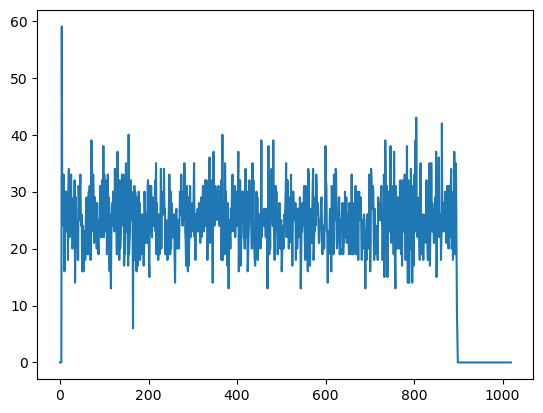

In [1]:
#!/usr/bin/env python

import sys
import os
from pathlib import Path

# Auto-locate project paths: notebook is under .../SPAD python/control
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name.lower() != 'control':
    NOTEBOOK_DIR = Path(r'D:/OneDrive/foam_imaging_project/experiment_setup/SPAD python/control')
PROJECT_DIR = NOTEBOOK_DIR.parent
EXPERIMENT_DIR = PROJECT_DIR.parent
SDK_PATH = str(PROJECT_DIR / 'samples')
if SDK_PATH not in sys.path:
    sys.path.append(SDK_PATH)
if hasattr(os, 'add_dll_directory'):
    try: os.add_dll_directory(SDK_PATH)
    except OSError: pass

import ctypes
from PF32_Factory import PF32_Factory
from PF32_Camera import PF32_Camera
import array
from io import StringIO
import platform


write_to_file = False

factory = PF32_Factory(SDK_PATH)
factory.setLogStreamLevel(PF32_Factory.LOGLEVEL_TRACE)
camera = factory.PF_construct()

print("Reading histogram data")

camera.setMode(PF32_Camera.MODE_TCSPC_LASER_MASTER)
camera.setExposure_us(100)
camera.setFramesToSum(1) # So driver doesn't try to set TDC's beyond range

no_of_seconds = 5
histogram = camera.getHistogram(no_of_seconds)
histogram_data_str = StringIO()

no_of_pixels = camera.getNoOfPixels()
no_of_TDC_codes = camera.getNoOfTDCCodes()

for p in range(0, no_of_pixels):
    histogram_data_str.write("Pixel " + str(p) + "\n")
    for t in range(0, no_of_TDC_codes):
        histogram_data_str.write(str(histogram[(p * no_of_TDC_codes) + t]) + " ")
    histogram_data_str.write("\n")
histogram_data_str.write("\n")

if write_to_file:
    histogram_data = open("swHistogram.dat", "w")
    histogram_data.write(histogram_data_str.getvalue())
    histogram_data.close()
else:
    print(histogram_data_str.getvalue())

print(camera.getSync_Hz())

print(f'frames = {camera.getNoOfFramesToHistogram()}')
factory.PF_destruct(camera)

import matplotlib.pyplot as plt

pixel_index = 0
plt.figure()
plt.plot(histogram[4+1024*pixel_index:1024+1024*pixel_index])
plt.show()

In [4]:
1024*1024

1048576

### original get histogram via hardware

In [10]:
#!/usr/bin/env python
import sys
import os
from pathlib import Path

# Auto-locate project paths: notebook is under .../SPAD python/control
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name.lower() != 'control':
    NOTEBOOK_DIR = Path(r'D:/OneDrive/foam_imaging_project/experiment_setup/SPAD python/control')
PROJECT_DIR = NOTEBOOK_DIR.parent
EXPERIMENT_DIR = PROJECT_DIR.parent
SDK_PATH = str(PROJECT_DIR / 'samples')
if SDK_PATH not in sys.path:
    sys.path.append(SDK_PATH)
if hasattr(os, 'add_dll_directory'):
    try: os.add_dll_directory(SDK_PATH)
    except OSError: pass

import ctypes
from PF32_Factory import PF32_Factory
from PF32_Camera import PF32_Camera
import array
from io import StringIO
import platform


write_to_file = False;

path_to_library = './'
firmwareFile = str(EXPERIMENT_DIR / 'Firmware' / 'PF32_USBC_Hist.bit')

factory = PF32_Factory(SDK_PATH)
factory.setLogStreamLevel(PF32_Factory.LOGLEVEL_TRACE)
camera = factory.PF_constructWithCustomFirmware(firmwareFile)

# Can also do:
#camera = factory.PF_construct()
#camera.loadCustomFirmware(firmwareFile)


camera.setMode(PF32_Camera.MODE_PHOTON_COUNTING);

camera.setExposure_us(40) 
camera.setNoOfFramesToHistogram(100)
camera.setNoOfBinsInHistogram(0); # 0 means all the bins available which is 1024

print("Reading histogram data")

no_of_histograms = 4
histogram = camera.getHistogramsFromFirmware(no_of_histograms)

no_of_pixels = camera.getNoOfPixels()
no_of_bins_in_histogram = camera.getNoOfBinsInHistogram()

histogram_data_str = StringIO()

for h in range(0, no_of_histograms):
    histogram_data_str.write("Histogram=" + str(h) + "\n")
    for p in range(0, no_of_pixels):
        histogram_data_str.write("Pixel=" + str(p) + "\n")
        for t in range(0, no_of_bins_in_histogram):
            histogram_data_str.write(str(histogram[(p * no_of_bins_in_histogram) + t]) + " ")
        histogram_data_str.write("\n")
    histogram_data_str.write("\n")
histogram_data_str.write("\n")

if write_to_file:
    histogram_data = open("fwHistogram.dat", "w");
    histogram_data.write(histogram_data_str.getvalue())
    histogram_data.close()
else:
    print(histogram_data_str.getvalue())


factory.PF_destruct(camera)



Reading histogram data
Histogram=0
Pixel=0

Pixel=1

Pixel=2

Pixel=3

Pixel=4

Pixel=5

Pixel=6

Pixel=7

Pixel=8

Pixel=9

Pixel=10

Pixel=11

Pixel=12

Pixel=13

Pixel=14

Pixel=15

Pixel=16

Pixel=17

Pixel=18

Pixel=19

Pixel=20

Pixel=21

Pixel=22

Pixel=23

Pixel=24

Pixel=25

Pixel=26

Pixel=27

Pixel=28

Pixel=29

Pixel=30

Pixel=31

Pixel=32

Pixel=33

Pixel=34

Pixel=35

Pixel=36

Pixel=37

Pixel=38

Pixel=39

Pixel=40

Pixel=41

Pixel=42

Pixel=43

Pixel=44

Pixel=45

Pixel=46

Pixel=47

Pixel=48

Pixel=49

Pixel=50

Pixel=51

Pixel=52

Pixel=53

Pixel=54

Pixel=55

Pixel=56

Pixel=57

Pixel=58

Pixel=59

Pixel=60

Pixel=61

Pixel=62

Pixel=63

Pixel=64

Pixel=65

Pixel=66

Pixel=67

Pixel=68

Pixel=69

Pixel=70

Pixel=71

Pixel=72

Pixel=73

Pixel=74

Pixel=75

Pixel=76

Pixel=77

Pixel=78

Pixel=79

Pixel=80

Pixel=81

Pixel=82

Pixel=83

Pixel=84

Pixel=85

Pixel=86

Pixel=87

Pixel=88

Pixel=89

Pixel=90

Pixel=91

Pixel=92

Pixel=93

Pixel=94

Pixel=95

Pixel=96

Pixel